In [14]:
import numpy as np
import pandas as pd

In [16]:
df=pd.read_csv('/content/placement.csv')

In [17]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [18]:
df=df.iloc[:,1:]

DATA PREPROCESSING

In [19]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [20]:
import matplotlib.pyplot as plt

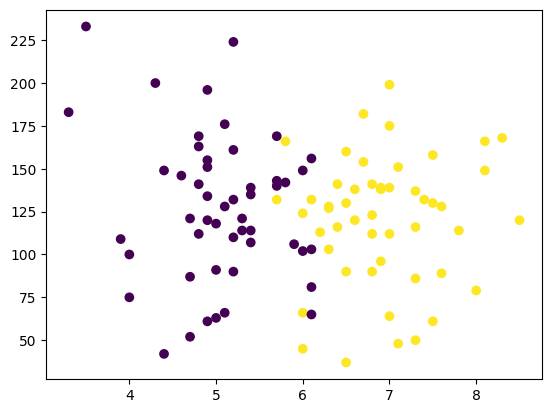

In [21]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [22]:
X=df.iloc[:,0:2]

In [23]:
Y=df.iloc[:,-1]

In [24]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [25]:
Y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train,X_test,Y_train,Y_test =train_test_split(X,Y,test_size=0.1)

In [28]:
X_test

,cgpa,iq
21,7.1,151.0
35,6.8,90.0
34,4.8,163.0
92,5.2,110.0
74,6.7,154.0
31,3.9,109.0
32,7.0,139.0
26,7.0,199.0
65,8.1,166.0
81,5.4,107.0


In [29]:
X_train

,cgpa,iq
6,5.7,143.0
20,6.6,120.0
72,7.3,116.0
19,5.2,132.0
58,8.0,79.0
...,...,...
8,6.1,156.0
24,4.7,121.0
85,5.8,166.0
39,4.6,146.0


In [30]:
X_test

,cgpa,iq
21,7.1,151.0
35,6.8,90.0
34,4.8,163.0
92,5.2,110.0
74,6.7,154.0
31,3.9,109.0
32,7.0,139.0
26,7.0,199.0
65,8.1,166.0
81,5.4,107.0


In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()

In [33]:
X_train=scaler.fit_transform(X_train)

In [34]:
X_train

array([[-0.23813939,  0.52605469],
       [ 0.5622461 , -0.04706805],
       [ 1.18476815, -0.14674157],
       [-0.68279799,  0.25195251],
       [ 1.80729019, -1.06872162],
       [ 0.02865578, -1.39266056],
       [ 0.74010954,  0.47621793],
       [ 0.5622461 ,  0.40146279],
       [ 0.02865578, -1.91594654],
       [ 0.91797299,  1.32344284],
       [ 1.36263159,  0.20211575],
       [ 0.38438266,  0.47621793],
       [-0.86066143, -1.4674157 ],
       [ 0.02865578, -0.49559889],
       [-0.94959315,  1.84672882],
       [-1.74997864, -0.54543565],
       [-0.59386627, -0.02214967],
       [-1.74997864, -1.16839514],
       [ 0.02865578,  0.67556496],
       [ 0.1175875 , -0.47068051],
       [ 1.36263159, -1.51725246],
       [-0.94959315,  0.30178927],
       [-0.68279799, -0.79461945],
       [ 0.82904126,  0.42638117],
       [-1.03852487,  0.47621793],
       [-0.06027594, -0.39592537],
       [ 1.89622192,  0.67556496],
       [ 2.07408536,  1.14901418],
       [ 0.74010954,

In [35]:
X_test=scaler.transform(X_test)

In [36]:
X_test

array([[ 1.00690471,  0.72540172],
       [ 0.74010954, -0.79461945],
       [-1.03852487,  1.02442228],
       [-0.68279799, -0.29625185],
       [ 0.65117782,  0.80015686],
       [-1.83891036, -0.32117023],
       [ 0.91797299,  0.42638117],
       [ 0.91797299,  1.92148396],
       [ 1.89622192,  1.09917742],
       [-0.50493455, -0.37100699]])

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
clf=LogisticRegression()

In [39]:
clf.fit(X_train,Y_train) #training data

LogisticRegression()

In [40]:
y_pre=clf.predict(X_test)

In [41]:
y_pre

array([1, 1, 0, 0, 1, 0, 1, 1, 1, 0])

In [42]:
Y_test

,placement
21,1
35,1
34,0
92,0
74,1
31,0
32,1
26,1
65,1
81,0


In [43]:
from sklearn.metrics import accuracy_score

In [44]:
accuracy_score(Y_test,y_pre)

1.0

In [45]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

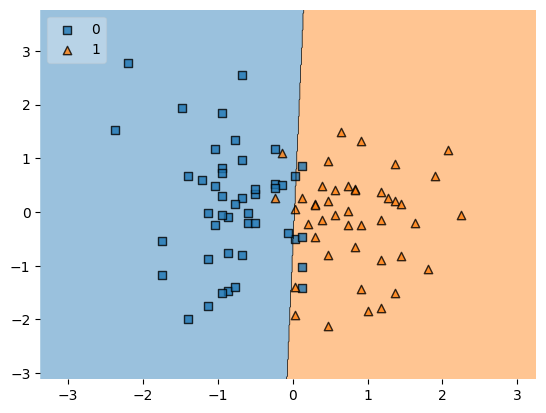

In [46]:
plot_decision_regions(X_train,Y_train.values, clf=clf, legend=2)

In [47]:
import pickle

In [51]:
pickle.dump(clf, open('model.pkl', 'wb'))